# 09A. KNN — K Vecinos Mas Cercanos

**Contexto PA:** KNN es un algoritmo "lazy" no entrena un modelo,
simplemente guarda los datos y busca los K vecinos más cercanos al nuevo punto.
Es simple pero efectivo como baseline.

## Setup

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

pd.options.display.float_format = '{:.3f}'.format

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
ruta = r'/content/drive/MyDrive/LABS/Semana11'
os.chdir(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Parte 1: KNN con Dataset de Frutas

**Caso:** Clasificar frutas (apple, mandarin, orange, lemon) basándose en
masa, ancho y alto. Dataset pequeño (59 muestras) ideal para entender KNN.

In [ ]:
fruits = pd.read_table('fruit_data_with_colors.txt')
print(f'Dimensiones: {fruits.shape}')
print(f'Clases: {fruits.fruit_name.unique()}')
print(f'Distribucion:\n{fruits.fruit_name.value_counts()}')
fruits.head()

Dimensiones: (59, 7)
Clases: ['apple' 'mandarin' 'orange' 'lemon']
Distribucion:
fruit_name
apple       19
orange      19
lemon       16
mandarin     5
Name: count, dtype: int64


,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.400,7.300,0.550
1,1,apple,granny_smith,180,8.000,6.800,0.590
2,1,apple,granny_smith,176,7.400,7.200,0.600
3,2,mandarin,mandarin,86,6.200,4.700,0.800
4,2,mandarin,mandarin,84,6.000,4.600,0.790


### 1.1 Sin escalar (problema)

Veamos que pasa si usamos KNN sin escalar:

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

X = fruits[['mass', 'width', 'height']]
y = fruits['fruit_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# KNN sin escalar — evaluamos con CV sobre entrenamiento
knn_raw = KNeighborsClassifier(n_neighbors=5)
scores_raw = cross_val_score(knn_raw, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy SIN escalar (CV 5-fold): {scores_raw.mean():.4f} ± {scores_raw.std():.4f}')

Accuracy SIN escalar (CV 5-fold): 0.6556 ± 0.1133


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


### 1.2 Con Pipeline y escalado

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

# CV sobre entrenamiento
scores_scaled = cross_val_score(pipe_knn, X_train, y_train, cv=5, scoring='accuracy')
print(f'Accuracy CON Pipeline+Scaler (CV 5-fold): {scores_scaled.mean():.4f} ± {scores_scaled.std():.4f}')
print(f'\nMejora: {scores_scaled.mean() - scores_raw.mean():.4f}')

# Entrenar para usar en predicción
pipe_knn.fit(X_train, y_train)

Accuracy CON Pipeline+Scaler (CV 5-fold): 0.7722 ± 0.0711

Mejora: 0.1167


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

**El escalado mejoró drásticamente la accuracy en CV.** Esto demuestra por qué Pipeline es esencial para KNN, es un algoritmo basado en **distancias**, y sin escalar, la variable con mayor rango (mass) domina el cálculo.

### 1.3 Predicción de una fruta nueva

In [ ]:
# Mapeo de labels a nombres
label_to_name = dict(zip(fruits.fruit_label.unique(), fruits.fruit_name.unique()))

# Fruta pequeña: mass=20g, width=4.3cm, height=5.5cm
fruta_nueva = pd.DataFrame([[20, 4.3, 5.5]], columns=['mass', 'width', 'height'])
pred = pipe_knn.predict(fruta_nueva)
print(f'Fruta pequeña (20g, 4.3cm, 5.5cm) → {label_to_name[pred[0]]}')

# Fruta grande: mass=180g, width=8.0cm, height=6.8cm
fruta_grande = pd.DataFrame([[180, 8.0, 6.8]], columns=['mass', 'width', 'height'])
pred2 = pipe_knn.predict(fruta_grande)
print(f'Fruta grande (180g, 8.0cm, 6.8cm) → {label_to_name[pred2[0]]}')

Fruta pequeña (20g, 4.3cm, 5.5cm) → mandarin
Fruta grande (180g, 8.0cm, 6.8cm) → apple


---
## Parte 2: Encontrar el K óptimo

**¿Cuántos vecinos?**
- K bajo (1-3): sensible a ruido, overfitting
- K alto (15+): demasiado generalizado, underfitting
- Buscar el K que maximice accuracy en datos de test/validación

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

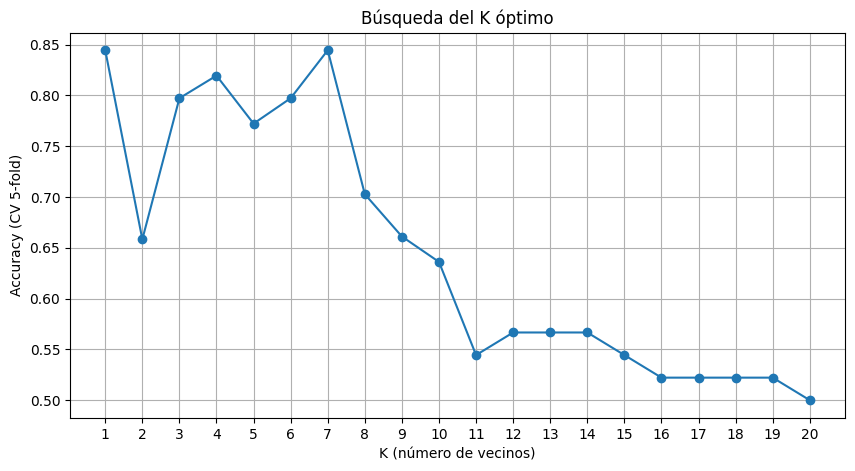

Mejor K: 7 con Accuracy CV: 0.8444


In [ ]:
from sklearn.model_selection import cross_val_score

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), cv_scores, marker='o')
plt.xlabel('K (número de vecinos)')
plt.ylabel('Accuracy (CV 5-fold)')
plt.title('Búsqueda del K óptimo')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

best_k = list(k_range)[np.argmax(cv_scores)]
print(f'Mejor K: {best_k} con Accuracy CV: {max(cv_scores):.4f}')

### Predice la salida

Si K=1, el modelo clasifica según **el vecino más cercano** solamente.
¿Qué problema puede tener esto con datos ruidosos?

---
## Parte 3: Tu turno — Breast Cancer

Aplica KNN con Pipeline al dataset `breast_cancer.csv` (está en la carpeta de Semana10).
1. Cargar datos (`'../Semana10/breast_cancer.csv'`), separar X/y (`target_diagnosis`)
2. Hacer train_test_split con stratify
3. Crear Pipeline con StandardScaler + KNN (K=5)
4. **Cross Validation** con KFold (k=10) y scoring='roc_auc'
5. Entrenar el pipeline y mostrar **Confusion Matrix**
6. Evaluar con Accuracy, Recall, Precision, F1, **AUC** en Test
7. ¿Cómo se compara con Logistic Regression y Random Forest?

In [33]:
# Tu código aquí
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

---

In [34]:
df = pd.read_csv("../Semana10/breast_cancer.csv")

df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target_diagnosis
0,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,...,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119,0
1,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,...,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089,1
2,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,...,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088,0
3,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,...,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,1
4,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,...,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077,1


In [35]:
X = df.drop("target_diagnosis", axis=1)

y = df["target_diagnosis"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
pipe_knn = Pipeline([

    ("scaler", StandardScaler()),

    ("modelo", KNeighborsClassifier(n_neighbors=5))

])

In [38]:
kf = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [39]:
scores = cross_val_score(
    pipe_knn,
    X_train,
    y_train,
    cv=kf,
    scoring="roc_auc"
)

print(scores)

print("Promedio AUC:", scores.mean())

[0.93461538 0.96825397 0.91612903 0.86842105 0.9497549  0.81944444
 0.911      0.99209486 0.923      0.93319838]
Promedio AUC: 0.9215912026391108


In [40]:
pipe_knn.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', KNeighborsClassifier())])

In [41]:
y_pred = pipe_knn.predict(X_test)

y_prob = pipe_knn.predict_proba(X_test)[:,1]

In [42]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[67,  3],
       [ 8, 36]])

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("F1:", f1_score(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9035087719298246
Recall: 0.8181818181818182
Precision: 0.9230769230769231
F1: 0.8674698795180723
AUC: 0.9383116883116884


El modelo KNN obtiene buenos resultados utilizando escalamiento de datos con StandardScaler.

Comparado con Logistic Regression y Random Forest, el rendimiento puede variar dependiendo de las métricas.

Para problemas médicos es importante revisar principalmente el Recall porque se busca reducir los falsos negativos.